# Revenue Analysis

In [7]:
import pandas as pd

In [8]:
from pathlib import Path
import sys

# Find dataframes.py in current folder or any parent folder
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / "dataframes.py").exists():
        sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("dataframes.py not found in current or parent directories")

from dataframes import (
    orders_df,
    customers_df,
    order_items_df,
    date_df,
    sellers_df,
    products_df,
    payments_df,
    reviews_df
)

# EDA

## Monthly Revenue Trend

In [9]:
# ---------------------------------------------
# Monthly Revenue with YoY Growth
# ---------------------------------------------

monthly_revenue = (
    df
    .groupby(pd.Grouper(key="order_date", freq="MS"))["total_revenue"]
    .sum()
    .reset_index()
    .rename(columns={
        "order_date": "Month",
        "total_revenue": "Revenue"
    })
)

# Last Year's Revenue
monthly_revenue["Last Year Revenue"] = monthly_revenue["Revenue"].shift(12)

# YoY %
monthly_revenue["YoY %"] = (
    (monthly_revenue["Revenue"] - monthly_revenue["Last Year Revenue"])
    / monthly_revenue["Last Year Revenue"]
    * 100
)

# ---------------------------------------------
# Pretty Formatting
# ---------------------------------------------

display_df = monthly_revenue.copy()

display_df["Month"] = display_df["Month"].dt.strftime("%b %Y")

display_df["Revenue"] = display_df["Revenue"].map(
    lambda x: f"${x:,.2f}"
)

display_df["Last Year Revenue"] = display_df["Last Year Revenue"].map(
    lambda x: f"${x:,.2f}" if pd.notna(x) else "-"
)

display_df["YoY %"] = display_df["YoY %"].map(
    lambda x: f"{x:.2f}%" if pd.notna(x) else "-"
)


NameError: name 'df' is not defined

In [ ]:
display(
    display_df.style
    .hide(axis="index")
    .set_caption("📈 Monthly Revenue & YoY Analysis")
    .format(na_rep="-")
    .set_properties(**{
        "text-align": "center",
        "font-size": "13px",
        "padding": "10px"
    })
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "18px"),
                ("font-weight", "bold"),
                ("padding", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#2E4053"),
                ("color", "white"),
                ("font-size", "13px"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center")
            ]
        }
    ])
)

In [10]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_revenue["Month"],
    monthly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Revenue")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14,5))

yoy_df = monthly_revenue.dropna(subset=["YoY %"])

plt.plot(
    yoy_df["Month"],
    yoy_df["YoY %"],
    marker="o",
    linewidth=2
)

plt.axhline(0, linestyle="--")

plt.title("Year-over-Year Growth (%)")
plt.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue by State

In [11]:
df = (
    orders_df
    .merge(order_items_df, on="order_id", how="left")
    .merge(customers_df, on="customer_id", how="left")
)

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83463 entries, 0 to 83462
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       83463 non-null  str           
 1   customer_id                    83463 non-null  str           
 2   order_status                   83463 non-null  str           
 3   order_date                     83463 non-null  object        
 4   order_delivered_customer_date  81076 non-null  datetime64[us]
 5   order_estimated_delivery_date  83463 non-null  datetime64[us]
 6   order_item_id                  82896 non-null  float64       
 7   product_id                     82896 non-null  str           
 8   seller_id                      82896 non-null  str           
 9   shipping_limit_date            82896 non-null  datetime64[us]
 10  price                          82896 non-null  float64       
 11  freight_value             

In [12]:
# Create revenue column
df["revenue"] = (
    df["price"].fillna(0) +
    df["freight_value"].fillna(0)
)

# Revenue by customer state
revenue_by_state = (
    df
    .groupby("customer_state", as_index=False)
    .agg(
        Total_Revenue=("revenue", "sum"),
        Total_Orders=("order_id", "nunique"),
        Customers=("customer_unique_id", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
)

# Round revenue
revenue_by_state["Total_Revenue"] = revenue_by_state["Total_Revenue"].round(2)

print(revenue_by_state)

   customer_state  Total_Revenue  Total_Orders  Customers
25             SP     4340626.14         30735      29938
18             RJ     1585203.03          9532       9268
10             MG     1347970.89          8499       8290
22             RS      658801.20          4004       3908
17             PR      590713.49          3690       3599
4              BA      459823.82          2515       2463
23             SC      448572.62          2718       2657
8              GO      266572.46          1498       1462
6              DF      249134.17          1545       1519
15             PE      237739.26          1228       1205
7              ES      237220.59          1488       1445
5              CE      209578.91          1006        994
13             PA      159844.25           728        716
12             MT      138163.21           666        647
9              MA      113501.22           550        537
11             MS      106598.53           545        531
14            

In [13]:
import pandas as pd
import plotly.express as px

# Revenue
df["revenue"] = (
    df["price"].fillna(0) +
    df["freight_value"].fillna(0)
)

# Revenue by state
revenue_by_state = (
    df
    .groupby("customer_state", as_index=False)["revenue"]
    .sum()
)

# Choropleth
fig = px.choropleth(
    revenue_by_state,
    locations="customer_state",
    locationmode="geojson-id",   # state abbreviations
    geojson="https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson",
    featureidkey="properties.sigla",
    color="revenue",
    color_continuous_scale="Viridis",
    hover_name="customer_state",
    hover_data={"revenue":":,.2f"},
    title="<b>Total Revenue by Customer State</b>"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    title_x=0.5,
    margin=dict(l=20, r=20, t=60, b=20),
    coloraxis_colorbar_title="Revenue"
)

fig.show()

# Outlier Transaction Detection

In [14]:
df = order_items_df

In [15]:
df . info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


In [16]:
order_value = (
    df.groupby("order_id")
      .agg(
          order_value=("price", "sum"),
          freight_value=("freight_value", "sum"),
          total_items=("order_item_id", "count")
      )
      .reset_index()
)

order_value["total_order_value"] = (
    order_value["order_value"] +
    order_value["freight_value"]
)

order_value.head()

,order_id,order_value,freight_value,total_items,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1,218.04


In [17]:
Q1 = order_value["total_order_value"].quantile(0.25)
Q3 = order_value["total_order_value"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

order_value["IQR_Outlier"] = (
    (order_value["total_order_value"] < lower) |
    (order_value["total_order_value"] > upper)
)

print(order_value["IQR_Outlier"].value_counts())

IQR_Outlier
False    90891
True      7775
Name: count, dtype: int64


In [18]:
from scipy.stats import zscore

order_value["Z_score"] = zscore(order_value["total_order_value"])

order_value["Z_Outlier"] = (
    order_value["Z_score"].abs() > 3
)

print(order_value["Z_Outlier"].value_counts())

Z_Outlier
False    96955
True      1711
Name: count, dtype: int64


In [19]:
print(order_value["total_order_value"].describe())

print(f"Number of IQR Outliers : {order_value['IQR_Outlier'].sum()}")
print(f"Percentage : {order_value['IQR_Outlier'].mean()*100:.2f}%")

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: total_order_value, dtype: float64
Number of IQR Outliers : 7775
Percentage : 7.88%


C:\Users\Aniket\AppData\Local\Temp\ipykernel_50256\3008249843.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


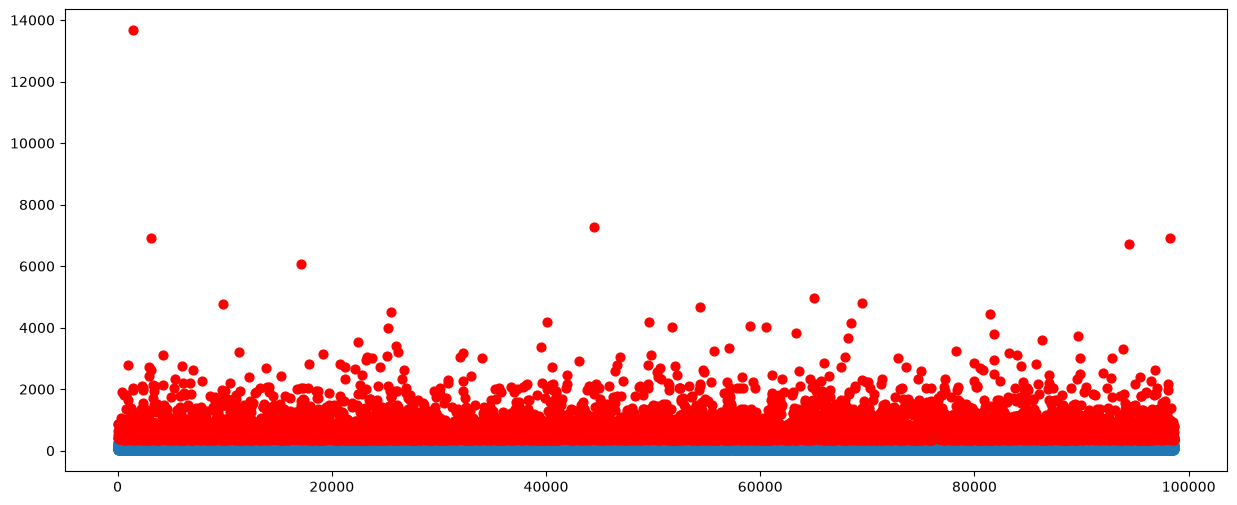

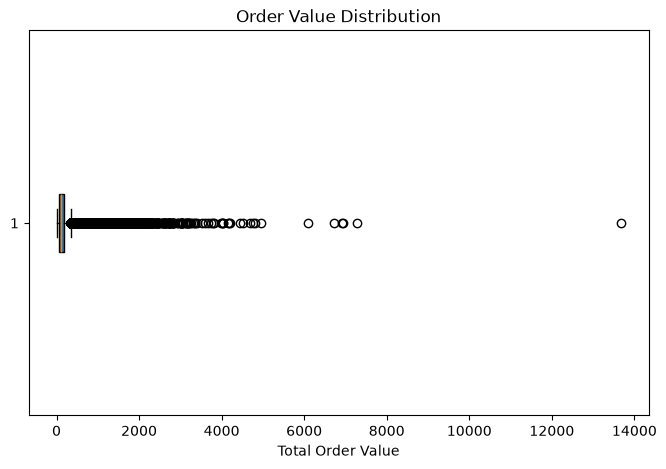

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

normal = order_value[~order_value["IQR_Outlier"]]
outliers = order_value[order_value["IQR_Outlier"]]

plt.scatter(
    normal.index,
    normal["total_order_value"],
    alpha=0.5,
    label="Normal"
)

plt.scatter(
    outliers.index,
    outliers["total_order_value"],
    color="red",
    s=40,
    label="Outlier"
)

plt.figure(figsize=(8,5))

plt.boxplot(
    order_value["total_order_value"],
    vert=False,
    patch_artist=True
)

plt.title("Order Value Distribution")
plt.xlabel("Total Order Value")

plt.show()

In [24]:
import numpy as np

In [22]:
# Merge orders with customers to get customer_unique_id
orders_customers = orders_df.merge(customers_df, on='customer_id', how='left')

# Merge order_items with orders (for dates, status)
order_items_full = order_items_df.merge(orders_df, on='order_id', how='left')

# Merge order_items with products (for category, if needed later)
order_items_full = order_items_full.merge(products_df, on='product_id', how='left')

# Filter to delivered orders only (common convention for revenue analysis)
delivered_orders = orders_df[orders_df['order_status'] == 'delivered'].copy()
delivered_orders['order_date'] = pd.to_datetime(delivered_orders['order_date'])
delivered_orders['year_month'] = delivered_orders['order_date'].dt.to_period('M')

print(f"Orders: {orders_df.shape}")
print(f"Order items: {order_items_df.shape}")
print(f"Delivered orders: {delivered_orders.shape}")

Orders: (73231, 6)
Order items: (112650, 7)
Delivered orders: (71055, 7)


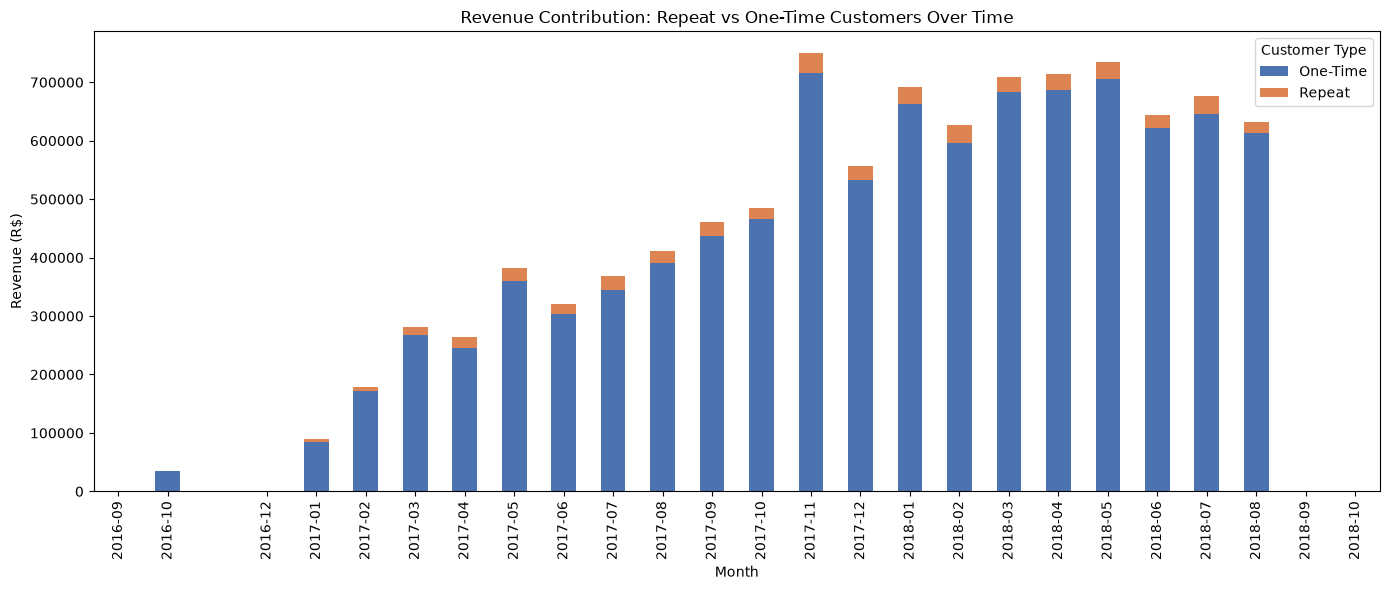

% Revenue from Repeat Customers: 4.38%


In [26]:
# ============================================================
# 1. REVENUE CONTRIBUTION: Repeat vs One-Time Customers
# ============================================================

# Count orders per unique customer
orders_per_customer = orders_customers.groupby('customer_unique_id')['order_id'].nunique().reset_index()
orders_per_customer.columns = ['customer_unique_id', 'order_count']
orders_per_customer['customer_type'] = np.where(
    orders_per_customer['order_count'] > 1, 'Repeat', 'One-Time'
)

# Get revenue per order (sum of order_items price)
order_revenue = order_items_df.groupby('order_id')['price'].sum().reset_index()
order_revenue.columns = ['order_id', 'order_revenue']

# Join order -> customer -> revenue
order_customer_revenue = orders_df[['order_id', 'customer_id']].merge(
    customers_df[['customer_id', 'customer_unique_id']], on='customer_id', how='left'
).merge(order_revenue, on='order_id', how='left')

# Bring in customer type
order_customer_revenue = order_customer_revenue.merge(
    orders_per_customer[['customer_unique_id', 'customer_type']],
    on='customer_unique_id', how='left'
)

# Revenue by customer type over time
order_customer_revenue = order_customer_revenue.merge(
    orders_df[['order_id', 'order_date']], on='order_id', how='left'
)
order_customer_revenue['order_date'] = pd.to_datetime(order_customer_revenue['order_date'])
order_customer_revenue['year_month'] = order_customer_revenue['order_date'].dt.to_period('M')

revenue_by_type_time = order_customer_revenue.groupby(
    ['year_month', 'customer_type']
)['order_revenue'].sum().unstack(fill_value=0)

# Plot: Stacked bar over time
revenue_by_type_time.plot(kind='bar', stacked=True, figsize=(14, 6),
                           color=['#4C72B0', '#DD8452'])
plt.title('Revenue Contribution: Repeat vs One-Time Customers Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue (R$)')
plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

# Summary %
total_by_type = order_customer_revenue.groupby('customer_type')['order_revenue'].sum()
pct_repeat = total_by_type.get('Repeat', 0) / total_by_type.sum() * 100
print(f"% Revenue from Repeat Customers: {pct_repeat:.2f}%")

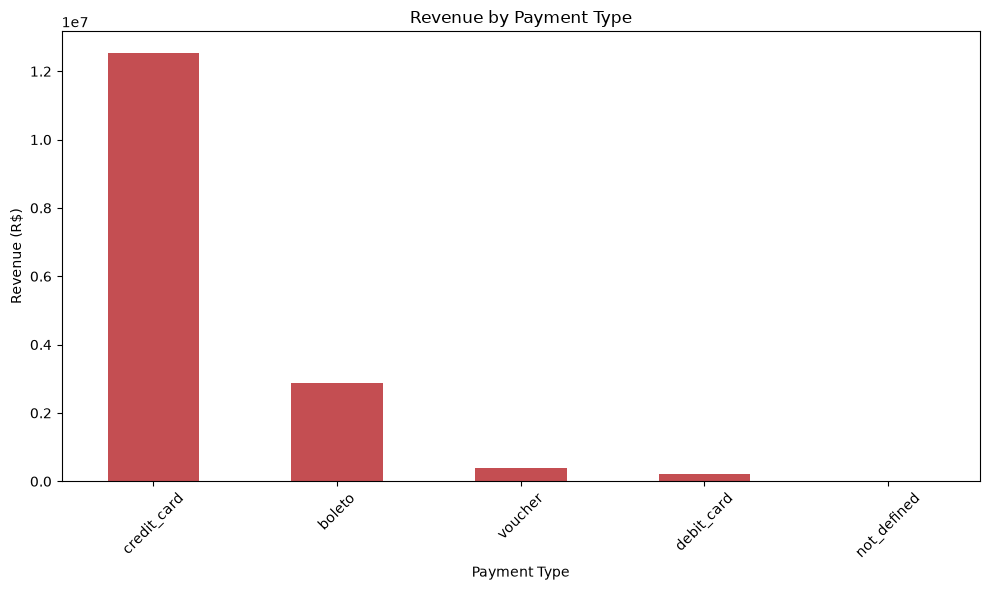

payment_type
credit_card    12542084.19
boleto          2869361.27
voucher          379436.87
debit_card       217989.79
not_defined           0.00
Name: payment_value, dtype: float64

% share:
payment_type
credit_card    78.34
boleto         17.92
voucher         2.37
debit_card      1.36
not_defined     0.00
Name: payment_value, dtype: float64


In [27]:
# ============================================================
# 3. REVENUE BY PAYMENT TYPE
# ============================================================

payment_order_revenue = payments_df.merge(order_revenue, on='order_id', how='left')

# Revenue attributed by payment_type (using payment_value, which reflects actual paid amount)
revenue_by_payment = payments_df.groupby('payment_type')['payment_value'].sum().sort_values(ascending=False)

# Plot: Bar chart
plt.figure(figsize=(10, 6))
revenue_by_payment.plot(kind='bar', color='#C44E52')
plt.title('Revenue by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(revenue_by_payment)
print(f"\n% share:\n{(revenue_by_payment / revenue_by_payment.sum() * 100).round(2)}")

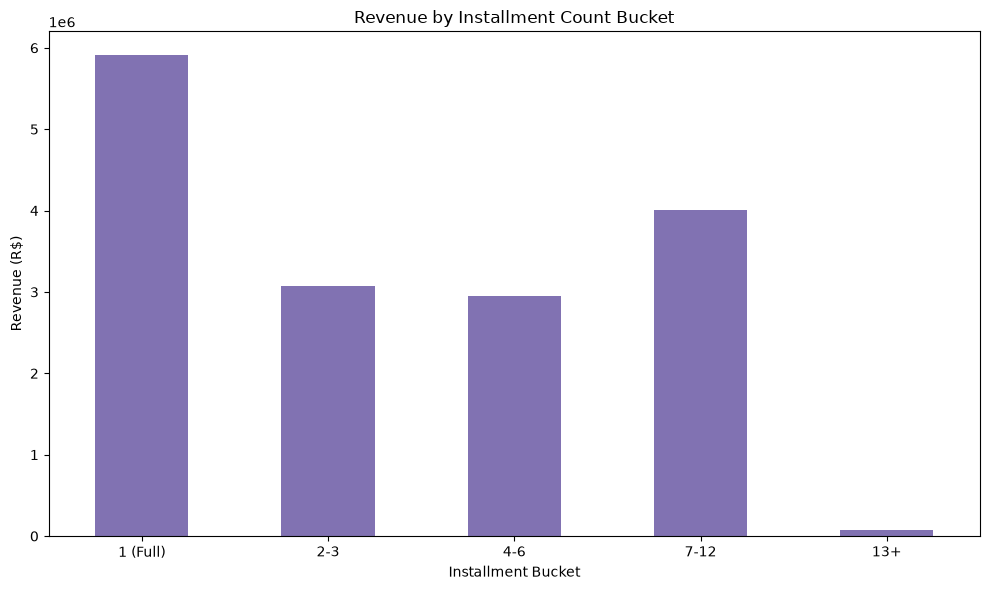

,total_revenue,avg_order_value,order_count
installment_bucket,,,
1 (Full),5907421.99,112.419540,52548
2-3,3070386.83,134.230429,22874
4-6,2947693.72,181.318430,16257
7-12,4006830.67,333.291521,12022
13+,76538.91,413.723838,185


In [28]:
# ============================================================
# 4. REVENUE BY INSTALLMENT COUNT
# ============================================================

# Bucket installments (1, 2-3, 4-6, 7-12, 13+)
def bucket_installments(n):
    if n <= 1:
        return '1 (Full)'
    elif n <= 3:
        return '2-3'
    elif n <= 6:
        return '4-6'
    elif n <= 12:
        return '7-12'
    else:
        return '13+'

payments_df['installment_bucket'] = payments_df['payment_installments'].apply(bucket_installments)

revenue_by_installments = payments_df.groupby('installment_bucket')['payment_value'].agg(
    total_revenue='sum',
    avg_order_value='mean',
    order_count='count'
).reindex(['1 (Full)', '2-3', '4-6', '7-12', '13+'])

# Plot: Bar chart
plt.figure(figsize=(10, 6))
revenue_by_installments['total_revenue'].plot(kind='bar', color='#8172B2')
plt.title('Revenue by Installment Count Bucket')
plt.xlabel('Installment Bucket')
plt.ylabel('Revenue (R$)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

revenue_by_installments

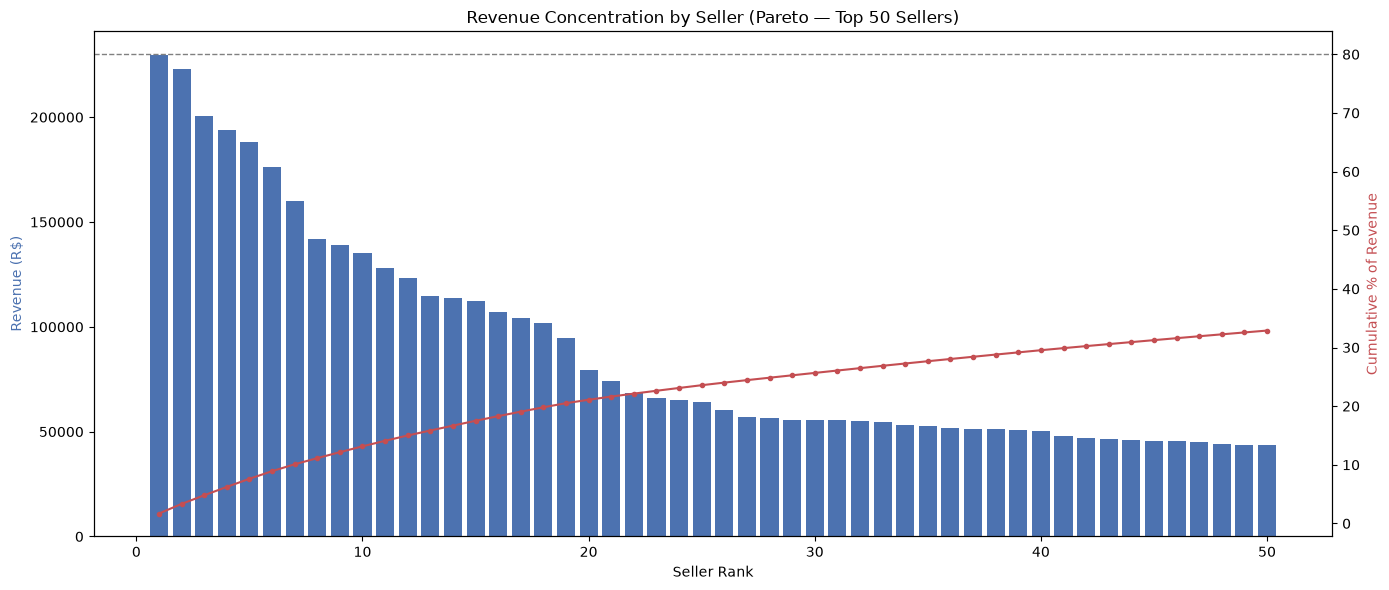

543 of 3095 sellers (17.5%) drive 80% of revenue


In [29]:
# ============================================================
# 5. REVENUE BY SELLER CONCENTRATION (Pareto)
# ============================================================

order_items_seller = order_items_df.merge(sellers_df[['seller_id']], on='seller_id', how='left')

revenue_by_seller = order_items_df.groupby('seller_id')['price'].sum().sort_values(ascending=False).reset_index()
revenue_by_seller.columns = ['seller_id', 'revenue']
revenue_by_seller['cumulative_revenue'] = revenue_by_seller['revenue'].cumsum()
revenue_by_seller['cumulative_pct'] = revenue_by_seller['cumulative_revenue'] / revenue_by_seller['revenue'].sum() * 100
revenue_by_seller['seller_rank'] = range(1, len(revenue_by_seller) + 1)

# Plot: Pareto chart (top 50 sellers for readability)
top_n = 50
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(revenue_by_seller['seller_rank'][:top_n], revenue_by_seller['revenue'][:top_n], color='#4C72B0')
ax1.set_xlabel('Seller Rank')
ax1.set_ylabel('Revenue (R$)', color='#4C72B0')

ax2 = ax1.twinx()
ax2.plot(revenue_by_seller['seller_rank'][:top_n], revenue_by_seller['cumulative_pct'][:top_n],
          color='#C44E52', marker='o', markersize=3)
ax2.set_ylabel('Cumulative % of Revenue', color='#C44E52')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)

plt.title('Revenue Concentration by Seller (Pareto — Top 50 Sellers)')
plt.tight_layout()
plt.show()

# % of sellers driving 80% of revenue
sellers_for_80pct = (revenue_by_seller['cumulative_pct'] <= 80).sum()
total_sellers = len(revenue_by_seller)
print(f"{sellers_for_80pct} of {total_sellers} sellers ({sellers_for_80pct/total_sellers*100:.1f}%) drive 80% of revenue")

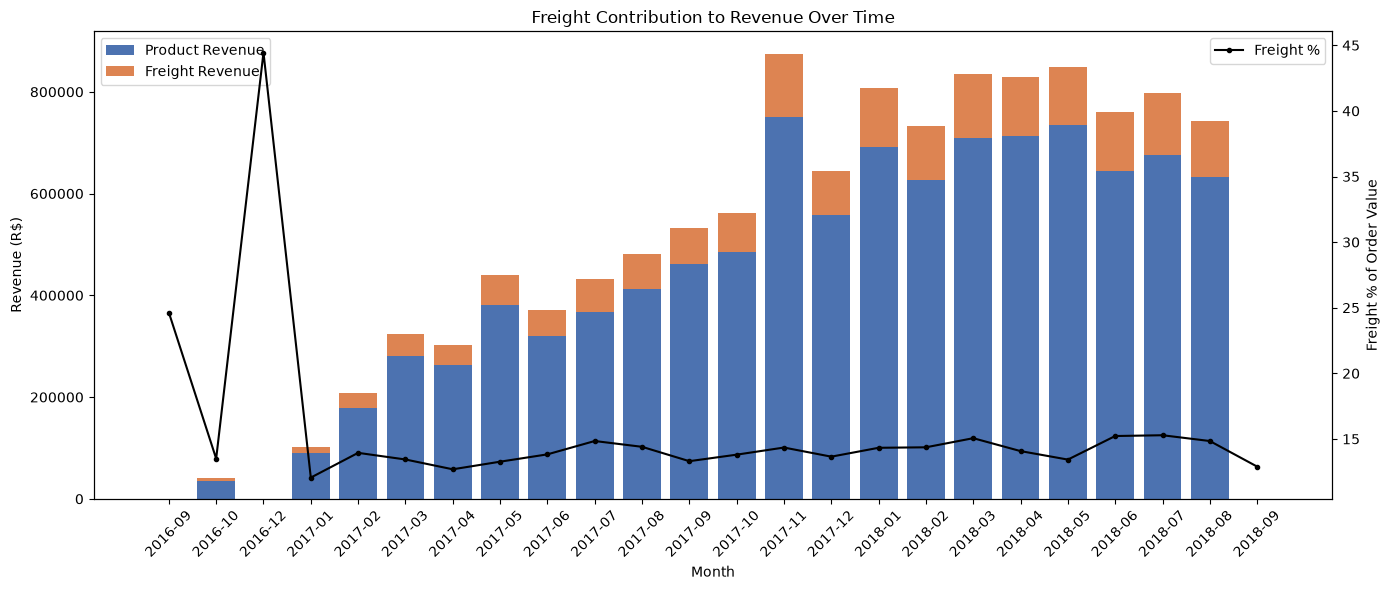

Average freight % of order value: 15.65%


In [31]:
# ============================================================
# 6. FREIGHT CONTRIBUTION TO REVENUE
# ============================================================

order_items_month = order_items_df.merge(
    orders_df[['order_id', 'order_date']], on='order_id', how='left'
)
order_items_month['order_date'] = pd.to_datetime(order_items_month['order_date'])
order_items_month['year_month'] = order_items_month['order_date'].dt.to_period('M')

freight_trend = order_items_month.groupby('year_month').agg(
    product_revenue=('price', 'sum'),
    freight_revenue=('freight_value', 'sum')
).reset_index()
freight_trend['total'] = freight_trend['product_revenue'] + freight_trend['freight_revenue']
freight_trend['freight_pct'] = freight_trend['freight_revenue'] / freight_trend['total'] * 100

# Plot: Stacked bar + trend line
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(freight_trend['year_month'].astype(str), freight_trend['product_revenue'],
        label='Product Revenue', color='#4C72B0')
ax1.bar(freight_trend['year_month'].astype(str), freight_trend['freight_revenue'],
        bottom=freight_trend['product_revenue'], label='Freight Revenue', color='#DD8452')
ax1.set_ylabel('Revenue (R$)')
ax1.set_xlabel('Month')
plt.xticks(rotation=45)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(freight_trend['year_month'].astype(str), freight_trend['freight_pct'],
         color='black', marker='o', markersize=3, label='Freight %')
ax2.set_ylabel('Freight % of Order Value')
ax2.legend(loc='upper right')

plt.title('Freight Contribution to Revenue Over Time')
plt.tight_layout()
plt.show()

print(f"Average freight % of order value: {freight_trend['freight_pct'].mean():.2f}%")